### **Modelo simplificado** con **concentración constante de fármaco**  ($\beta$ = $\beta_0$)

Como aproximación simplificada del modelo con tratamiento, se considera el caso en el que la concentración del fármaco se mantiene constante en el espacio y en el tiempo, es decir,

$$
\beta(x,t)\equiv \beta_0,
\qquad
\beta_0>0.
$$

Bajo esta hipótesis, no se resuelve la ecuación de evolución del fármaco y el sistema se reduce a una única ecuación para la densidad tumoral:

$$
\frac{\partial c}{\partial t}
-
\nabla \cdot \left(D(x)\nabla c\right)
=
a\, c \ln\left(\frac{K}{c}\right)
-
\gamma \beta_0\, c.
$$

El término $-\gamma \beta_0 c$ actúa como una tasa de mortalidad efectiva constante, que representa el efecto medio del tratamiento sobre la población tumoral.

Esta simplificación permite estudiar de forma más directa la competencia entre el crecimiento Gompertziano y la acción terapéutica, evitando la resolución de la ecuación de difusión y degradación del fármaco. Asimismo, proporciona un modelo de referencia útil para comparar los resultados obtenidos con el sistema completo acoplado

Carpeta creada en: C:\Users\fatim\Desktop\TFM_Simulacion_Con_Tratamiento
Número de pasos temporales: 150000
Condición CFL satisfecha: True


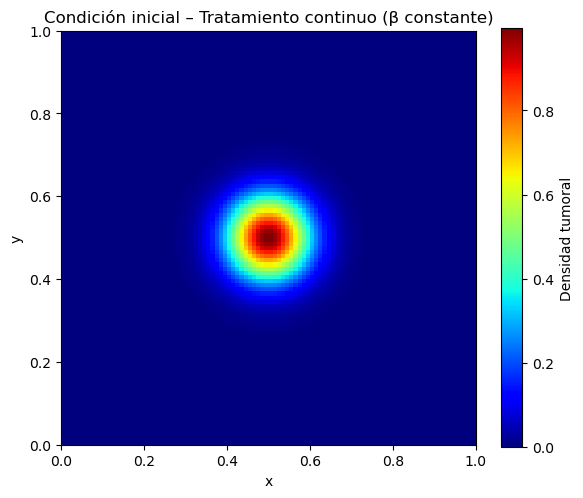

100%|██████████| 150000/150000 [01:49<00:00, 1364.23it/s]
C:\Users\fatim\AppData\Local\Temp\ipykernel_16112\1076344880.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


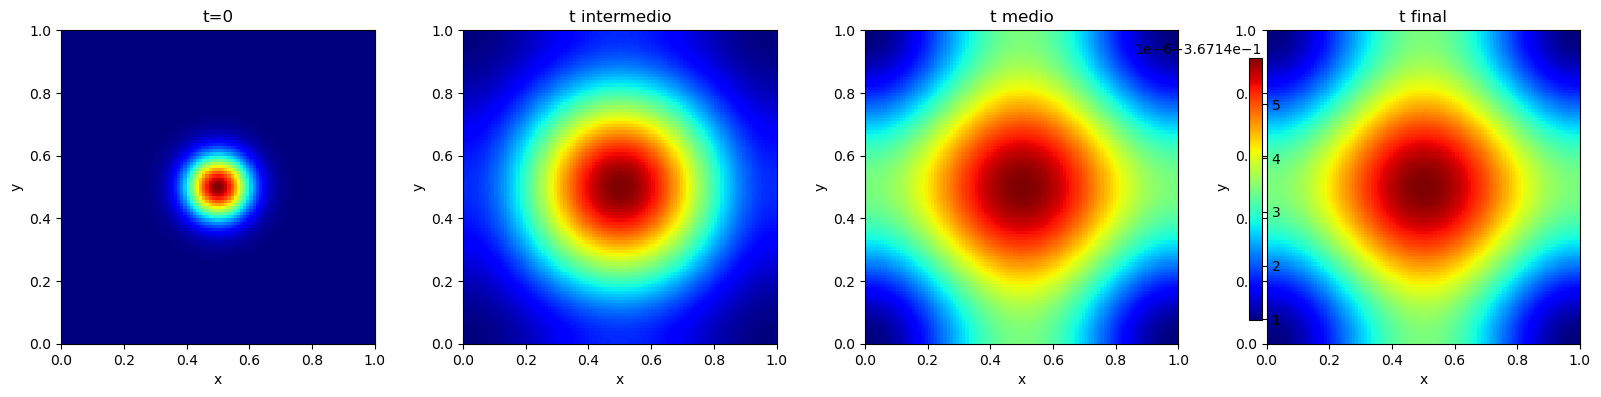

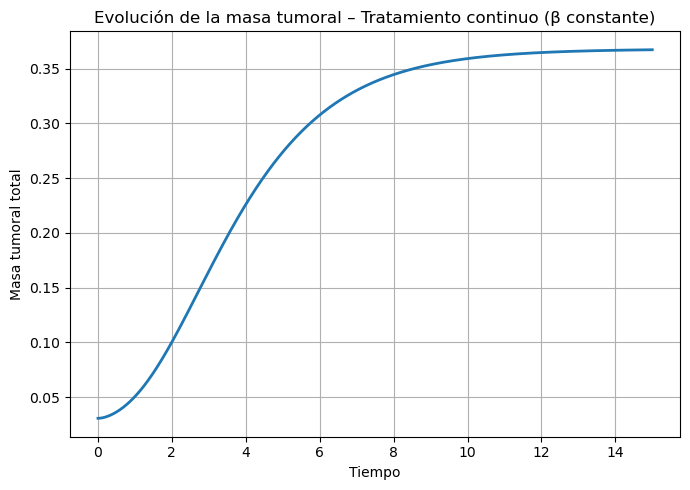


Simulación finalizada correctamente.
Archivos generados:
- condicion_inicial_tratamiento.png
- evolucion_tratamiento.png
- masa_tumoral_tratamiento.png
- evolucion_tratamiento.gif
Guardado en: C:\Users\fatim\Desktop\TFM_Simulacion_Con_Tratamiento


In [2]:
# =====================================================
# LIBRERÍAS
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import os
from tqdm import tqdm

# =====================================================
# CREAR CARPETA EN EL ESCRITORIO
# =====================================================

ruta_escritorio = os.path.join(os.path.expanduser("~"), "Desktop")
ruta_figuras = os.path.join(ruta_escritorio, "TFM_Simulacion_Con_Tratamiento")

os.makedirs(ruta_figuras, exist_ok=True)

print(f"Carpeta creada en: {ruta_figuras}")

# =====================================================
# PARÁMETROS DEL MODELO
# =====================================================

D = 0.01
a = 0.5
K = 1.0

beta0 = 0.5   # concentración constante del fármaco
gamma = 1.0   # eficacia del tratamiento

# =====================================================
# DOMINIO ESPACIAL
# =====================================================

Lx, Ly = 1.0, 1.0
Nx, Ny = 100, 100

dx = Lx / Nx
dy = Ly / Ny

x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)

X, Y = np.meshgrid(x, y, indexing='ij')

# =====================================================
# DISCRETIZACIÓN TEMPORAL
# =====================================================

T = 15.0
dt = 1e-4
Nt = int(T / dt)

print(f"Número de pasos temporales: {Nt}")

# =====================================================
# # CONDICION CFL
# =====================================================

cfl = dt <= dx**2 / (4 * D)
print(f"Condición CFL satisfecha: {cfl}")

# =====================================================
# CONDICIÓN INICIAL
# =====================================================

x0, y0 = 0.5, 0.5
sigma = 0.10
c0 = 1.0

c = c0 * np.exp(-((X - x0)**2 + (Y - y0)**2) / sigma**2)

# =====================================================
# FIGURA 1: CONDICIÓN INICIAL
# =====================================================

plt.figure(figsize=(6,5))
im = plt.imshow(c, extent=[0,1,0,1], origin='lower', cmap='jet')
plt.colorbar(im, label='Densidad tumoral')
plt.title('Condición inicial – Tratamiento continuo (β constante)')
plt.xlabel('x')
plt.ylabel('y')

plt.tight_layout()
plt.savefig(os.path.join(ruta_figuras, 'condicion_inicial_tratamiento.png'), dpi=300)
plt.show()

# =====================================================
# LAPLACIANO
# =====================================================

def laplaciano(Z):
    return (
        (np.roll(Z, -1, axis=0) - 2*Z + np.roll(Z, 1, axis=0)) / dx**2 +
        (np.roll(Z, -1, axis=1) - 2*Z + np.roll(Z, 1, axis=1)) / dy**2
    )

# =====================================================
# LISTAS PARA GUARDAR RESULTADOS
# =====================================================

masa = []
frames = []

# =====================================================
# SIMULACIÓN
# =====================================================

for n in tqdm(range(Nt)):

    c_old = c.copy()

    lap = laplaciano(c_old)

    reaction = a * c_old * np.log(K / (c_old + 1e-12))

    # =================================================
    # TRATAMIENTO (modelo simplificado)
    # =================================================
    treatment = gamma * beta0 * c_old

    # ecuación del tumor
    c = c_old + dt * (D * lap + reaction - treatment)

    # estabilidad numérica
    c = np.maximum(c, 0)

    # condiciones de Neumann
    c[0, :] = c[1, :]
    c[-1, :] = c[-2, :]
    c[:, 0] = c[:, 1]
    c[:, -1] = c[:, -2]

    # masa tumoral
    masa.append(np.sum(c) * dx * dy)

    # frames
    if n % 200 == 0:
        frames.append(c.copy())

# =====================================================
# FIGURA 2: EVOLUCIÓN ESPACIAL
# =====================================================

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

indices = [0, len(frames)//10, len(frames)//2, -1]

titulos = [
    't=0',
    't intermedio',
    't medio',
    't final'
]

for ax, idx, titulo in zip(axes, indices, titulos):

    im = ax.imshow(frames[idx], extent=[0,1,0,1],
                   origin='lower', cmap='jet')

    ax.set_title(titulo)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)

plt.tight_layout()
plt.savefig(os.path.join(ruta_figuras, 'evolucion_tratamiento.png'), dpi=300)
plt.show()

# =====================================================
# FIGURA 3: MASA TUMORAL
# =====================================================

plt.figure(figsize=(7,5))
plt.plot(np.linspace(0, T, len(masa)), masa, linewidth=2)

plt.xlabel('Tiempo')
plt.ylabel('Masa tumoral total')
plt.title('Evolución de la masa tumoral – Tratamiento continuo (β constante)')
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(ruta_figuras, 'masa_tumoral_tratamiento.png'), dpi=300)
plt.show()

# =====================================================
# GIF
# =====================================================

fig, ax = plt.subplots(figsize=(6,5))

im = ax.imshow(frames[0], extent=[0,1,0,1],
               origin='lower', cmap='jet', animated=True)

ax.set_title('Evolución tumoral – tratamiento continuo (β constante)')

def update(frame):
    im.set_array(frame)
    return [im]

ani = FuncAnimation(fig, update, frames=frames,
                    interval=100, blit=True)

ani.save(
    os.path.join(ruta_figuras, 'evolucion_tratamiento.gif'),
    writer=PillowWriter(fps=10)
)

plt.close()

# =====================================================
# MENSAJE FINAL
# =====================================================

print("\nSimulación finalizada correctamente.")
print("Archivos generados:")
print("- condicion_inicial_tratamiento.png")
print("- evolucion_tratamiento.png")
print("- masa_tumoral_tratamiento.png")
print("- evolucion_tratamiento.gif")

print(f"Guardado en: {ruta_figuras}")